### 1. Setup and Initialization
First, we define some constants and import the `KLT` class. This object will act as our central pipeline: it manages the underlying data, calculates the covariance matrix, stores the resulting eigenvalues and eigenvectors, and handles the signal reconstruction.

In [6]:
from KLT import KLT

FILE_PATH   = "data/blc5_2bit_guppi_57396_VOYAGER1_0002.0000.raw"
NUM_SAMPLES = 2**24
WINDOW_SIZE = 1024
N_EIGENVECS = 1

### 2. Finding the Best Channel
Next, we identify the best frequency channel using peak-finding logic directly from the GUPPI `.raw` file.

In [7]:
klt = KLT()
best_channel = klt.find_best_channel_guppi(FILE_PATH)

Raw data shape: (64, 516608, 2)  →  (channels, polarisations, samples)
Best channel: 44


### 3. Toeplitz KLT (T-KLT)
We apply the T-KLT variant to the signal. The method computes the covariance matrix, calculates the eigensystem, sorts it in descending order, and reconstructs the signal using only the requested number of principal components (eigenvectors). This essentially filters out the noise while retaining the primary structure of our signal.

Finally, we evaluate the success of the transform through visualizations:
- **Eigenspectrum**: Displays the distribution of eigenvalues, clearly highlighting which components were kept for the reconstruction and which were discarded as noise.
- **PSD Comparison**: Compares the Power Spectral Density of the original noisy signal against the reconstructed one, illustrating the noise floor reduction.


--- T-KLT ---
Starting sample extraction …


Progress: 517ksamples [00:06, 84.8ksamples/s]              


Loaded and normalised 1,000 samples.
T-KLT OK


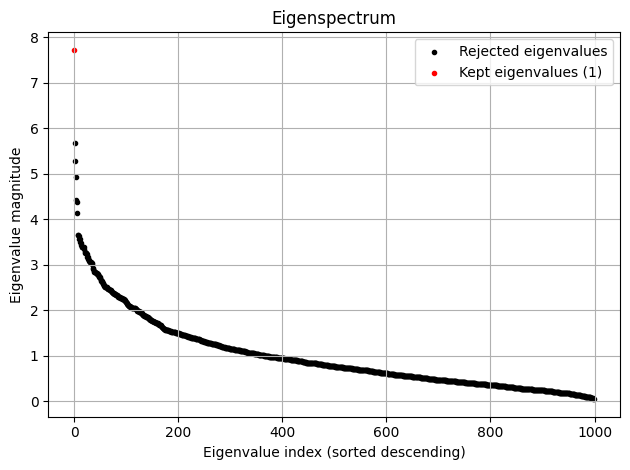

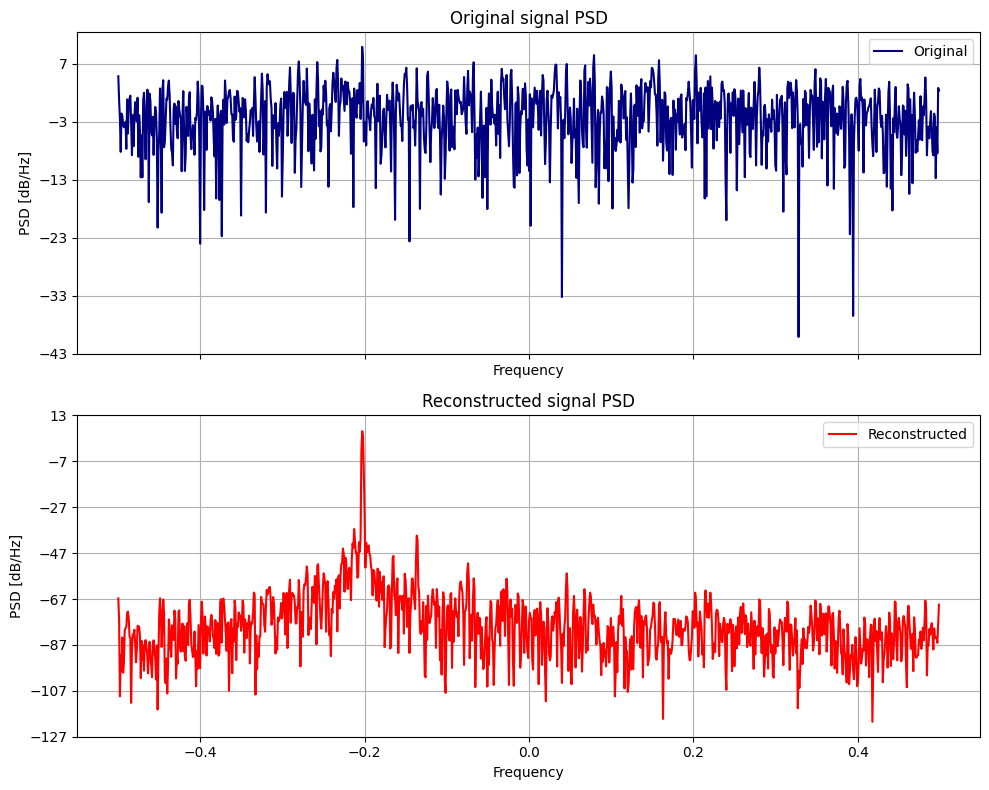

In [8]:
%matplotlib inline 

print("\n--- T-KLT ---")
klt = KLT()
klt.load_data_from_guppi(FILE_PATH, best_channel, num_samples=1000)  # keep num_samples low for T-KLT heavy algorithm
klt.apply_tklt(n_eigenvectors=N_EIGENVECS)
fig, ax = klt.plot_eigenspectrum(n_components=N_EIGENVECS)
fig2, ax2 = klt.plot_psd_comparison()
print("T-KLT OK")

### 4. Covariance KLT (C-KLT)
Now we apply the Covariance KLT using a specified window size. This variant segments the 1-D signal vector into non-overlapping windows to form a realization matrix.


--- C-KLT ---
Starting sample extraction …


Progress: 17.0Msamples [02:29, 114ksamples/s]                      


Loaded and normalised 16,777,216 samples.
C-KLT OK


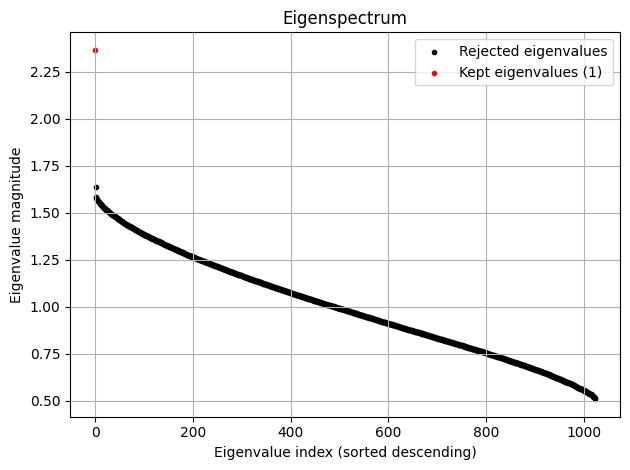

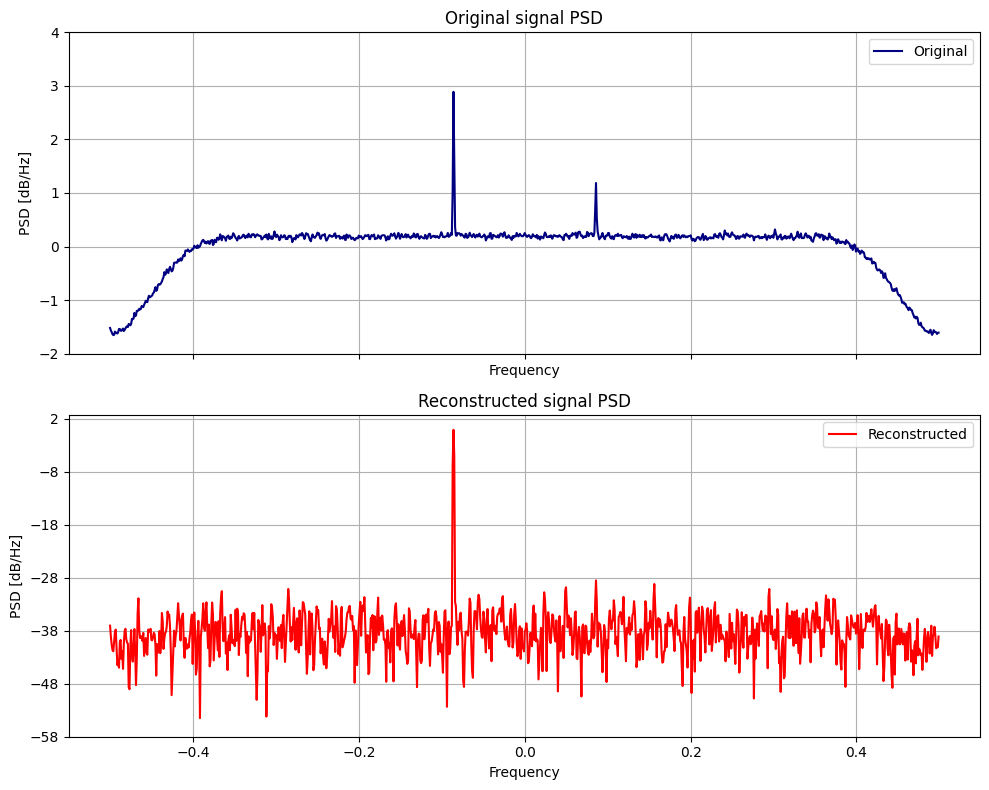

In [9]:
%matplotlib inline

print("\n--- C-KLT ---")
klt = KLT()
klt.load_data_from_guppi(FILE_PATH, best_channel, NUM_SAMPLES)
klt.apply_cklt(window_size=WINDOW_SIZE, n_eigenvectors=N_EIGENVECS)
fig3, ax3 = klt.plot_eigenspectrum(n_components=N_EIGENVECS)
fig4, ax4 = klt.plot_psd_comparison()
print("C-KLT OK")

In [ ]:
# We need more than 1-dimensional signal (e.g. Multi Antenna Array data).
# I keep the implementation here anyway for future data.
print("\n--- MR-KLT ---")

klt = KLT()
klt.load_data_from_guppi(FILE_PATH, best_channel, NUM_SAMPLES)

klt.apply_mrklt(n_eigenvectors=N_EIGENVECS)
klt.plot_eigenspectrum(n_components=N_EIGENVECS)
print("MR-KLT OK")